In [88]:
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib

from thinkbayes import _DictWrapper
import bisect

class Pmf(_DictWrapper):

    def Normalize(self, fraction=1.0):
        if self.log:
            raise ValueError("Pmf is under a log transforms")
        total = self.Total()
        if total == 0.0:
            raise ValueError("total probability is zero")
            return total
        factor = float(fraction)/total
        for x in self.d:
            self.d[x] *=factor
        return total

class Suite(Pmf):
    def Update(self, data):
        for hypo in list(self.Values()):
            like = self.Likelihood(data, hypo)
            self.Mult(hypo, like)
        return self.Normalize()
    def MakeCdf(self, name=None):
            return MakeCdfFromPmf(self, name=name)

def MakeCdfFromPmf(pmf, name=None):
    if name == None:
        name = pmf.name
    return MakeCdfFromItems(pmf.Items(), name)

def MakeCdfFromItems(items, name=''):
    runsum = 0
    xs = []
    cs = []

    for value, count in sorted(items):
        runsum += count
        xs.append(value)
        cs.append(runsum)

    total = float(runsum)
    ps = [c/total for c in cs]
    cdf = Cdf(xs, ps, name)
    return cdf




class Cdf(object):
    def __init__(self, xs=None, ps=None, name=''):
        self.xs = [] if xs is None else xs
        self.ps = [] if ps is None else ps
        self.name = name

    def Value(self,p):
        if p < 0 or p > 1:
            raise ValueError('Probability p must be in range [0, 1]')

        if p == 0: return self.xs[0]
        if p == 1: return self.xs[-1]
        index = bisect.bisect(self.ps, p)
        if p == self.ps[index - 1]:
            return self.xs[index - 1]
        else:
            return self.xs[index]

In [89]:
class Euro(Suite):
    def Likelihood(self, data, hypo):
        x = hypo
        if data == 'H':
            return x/100.0
        else:
            return 1 - x/100.0

In [90]:
def UniformPrior():
    suite = Euro(range(0,101))
    return suite

In [91]:
def TrianglePrior():
    suite = Euro()
    for x in range(0,51):
        suite.Set(x,x)
    for x in range(51,101):
        suite.Set(x,100-x)
    suite.Normalize
    return suite

def RunUpdate(suite, heads=140, tails=110):
    dataset = 'H'*heads + 'T'*tails
    for data in dataset:
        suite.Update(data)


Text(0.5, 1.0, 'ユーロ硬貨問題に対する一様事前確率と三角形事前確率')

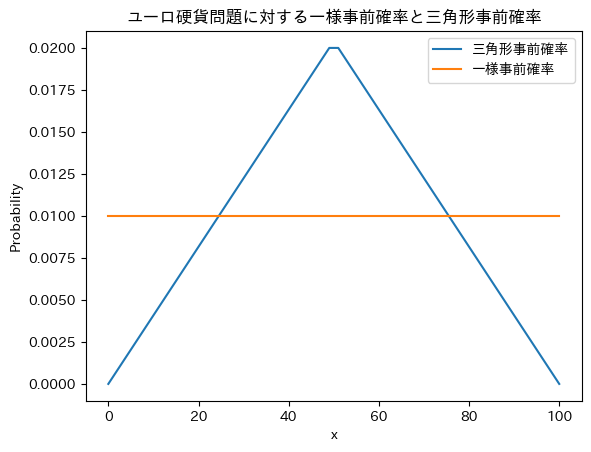

In [92]:
b_uni = UniformPrior()
b_uni.Remove(50)
b_uni.Normalize()

b_tri = TrianglePrior()
b_tri.Remove(50)
b_tri.Normalize()


xs, ps =zip(*b_tri.Items())
xs1, ps1 = zip(*b_uni.Items())

plt.plot(xs, ps, label='三角形事前確率')
plt.plot(xs1, ps1, label="一様事前確率")
plt.xlabel("x")
plt.ylabel("Probability")
plt.legend()
plt.title("ユーロ硬貨問題に対する一様事前確率と三角形事前確率")

Text(0.5, 1.0, 'ユーロ硬貨問題に対する一事後確率分布')

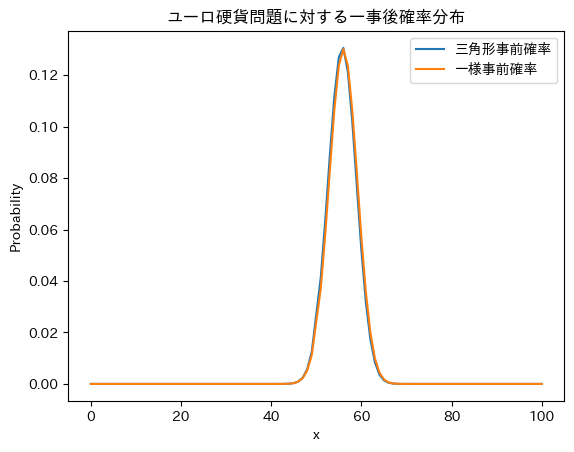

In [93]:
RunUpdate(b_tri)
RunUpdate(b_uni)

xs, ps =zip(*b_tri.Items())
xs1, ps1 = zip(*b_uni.Items())

plt.plot(xs, ps, label="三角形事前確率")
plt.plot(xs1, ps1, label="一様事前確率")
plt.xlabel("x")
plt.ylabel("Probability")
plt.legend()
plt.title("ユーロ硬貨問題に対する一事後確率分布")


In [94]:
items = b_tri.Items()

mle = max((prob, value) for value, prob in items)[1]
mean = sum(value * prob for value, prob in items)

print("Mean =", mean)
print("mle =", mle)

# CDFを作る
cdf = b_tri.MakeCdf()

# CDFからxsとpsを取り出す
xs, ps = cdf.xs, cdf.ps

# 5%点
p05 = xs[next(i for i, p in enumerate(ps) if p >= 0.05)]

# 95%点
p95 = xs[next(i for i, p in enumerate(ps) if p >= 0.95)]

print("90%区間 =", (p05, p95))

Mean = 55.88381390977269
mle = 56
90%区間 = (51, 61)


In [95]:
items = b_uni.Items()

mle = max((prob, value) for value, prob in items)[1]
mean = sum(value * prob for value, prob in items)

print("Mean =", mean)
print("mle =", mle)

# CDFを作る
cdf = b_uni.MakeCdf()

# CDFからxsとpsを取り出す
xs, ps = cdf.xs, cdf.ps

# 5%点
p05 = xs[next(i for i, p in enumerate(ps) if p >= 0.05)]

# 95%点
p95 = xs[next(i for i, p in enumerate(ps) if p >= 0.95)]

print("90%区間 =", (p05, p95))

Mean = 56.0799164792739
mle = 56
90%区間 = (51, 61)
